In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import torch

In [6]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

## Load Data

In [14]:
pulses_df = pd.read_csv("pulses.csv")

In [15]:
X = data.drop(columns=["row_id"], errors="ignore")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Clustering con K-Means

KMeans codo: 100%|██████████| 9/9 [00:03<00:00,  2.43it/s]


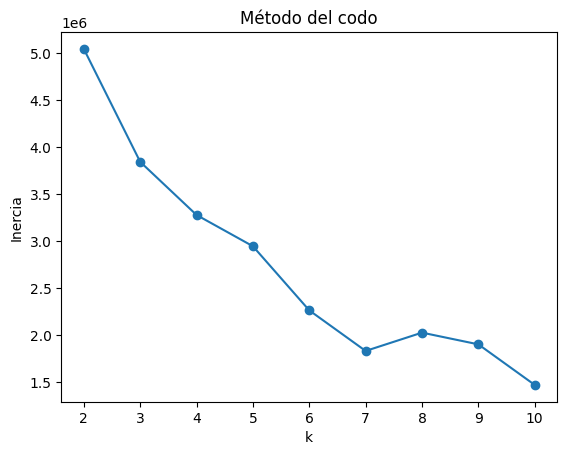

In [16]:
inertias = []
K_range = range(2, 11)
for k in tqdm(K_range, desc="KMeans codo"):
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker="o")
plt.title("Método del codo")
plt.xlabel("k"); plt.ylabel("Inercia"); plt.show()

In [17]:
best_k = 7
kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=42)
labels = kmeans.fit_predict(X_scaled)
pulses_df["cluster"] = labels

### PCA para visualización 2D/3D

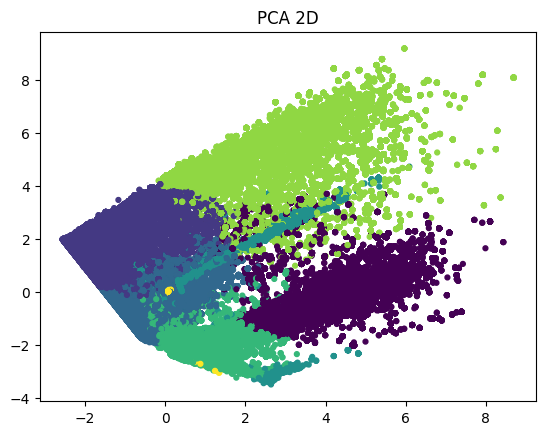

In [18]:
pca2 = PCA(n_components=2)
Xp2 = pca2.fit_transform(X_scaled)
plt.scatter(Xp2[:,0], Xp2[:,1], c=labels, s=12, cmap="viridis")
plt.title("PCA 2D"); plt.show()

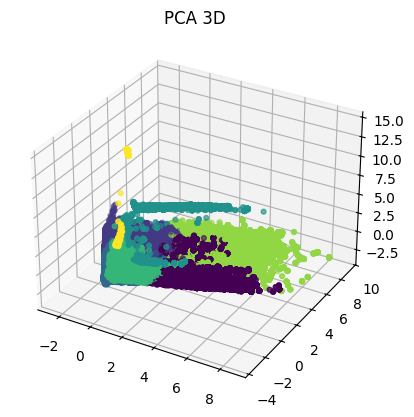

In [19]:
from mpl_toolkits.mplot3d import Axes3D
pca3 = PCA(n_components=3)
Xp3 = pca3.fit_transform(X_scaled)
fig = plt.figure(); ax = fig.add_subplot(111, projection="3d")
ax.scatter(Xp3[:,0], Xp3[:,1], Xp3[:,2], c=labels, s=12, cmap="viridis")
plt.title("PCA 3D"); plt.show()

# Modelos de  Clasificación

#### Dividir dataset

In [20]:
Xtr, Xte, ytr, yte = train_test_split(X_scaled, labels, test_size=0.2, random_state=42, stratify=labels)

## XGBoost

In [21]:
from xgboost import XGBClassifier

In [22]:
xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05)
xgb.fit(Xtr, ytr)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [23]:
print("\nXGBoost:")
print(classification_report(yte, xgb.predict(Xte)))


XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10802
           1       1.00      1.00      1.00     34271
           2       1.00      1.00      1.00     31531
           3       1.00      1.00      1.00      2475
           4       1.00      1.00      1.00     25257
           5       1.00      1.00      1.00      5334
           6       1.00      1.00      1.00        49

    accuracy                           1.00    109719
   macro avg       1.00      1.00      1.00    109719
weighted avg       1.00      1.00      1.00    109719



## MLP 

In [1]:
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA: True
NVIDIA A2


In [52]:
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

In [30]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, out_dim)
        )
    def forward(self, x): return self.net(x)

In [41]:
def train_model(model, Xtr, ytr, Xte, yte, epochs=20, bs=64, lr=1e-3, patience=5):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    Xtr, ytr = torch.tensor(Xtr, dtype=torch.float32), torch.tensor(ytr, dtype=torch.long)
    Xte, yte = torch.tensor(Xte, dtype=torch.float32), torch.tensor(yte, dtype=torch.long)
    train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=bs, shuffle=True)
    
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    patience_counter = 0
    history = {"train_loss": [], "val_loss": []}
    
    for epoch in range(1, epochs+1):
        # ---- Train ----
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(Xtr)

        # ---- Validation ----
        model.eval()
        with torch.no_grad():
            logits_val = model(Xte.to(device))
            val_loss = loss_fn(logits_val, yte.to(device)).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # ---- Early stopping ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping en epoch {epoch}")
                break
                
    model.load_state_dict(best_state)

    plt.figure(figsize=(6,4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Curva de aprendizaje (MLP)")
    plt.legend()
    plt.grid(True)
    plt.show()
                
    #

    return model


In [42]:
mlp = MLP(Xtr.shape[1], len(np.unique(labels)))

Epoch 001 | Train Loss: 0.0779 | Val Loss: 0.0162
Epoch 002 | Train Loss: 0.0130 | Val Loss: 0.0102
Epoch 003 | Train Loss: 0.0094 | Val Loss: 0.0110
Epoch 004 | Train Loss: 0.0085 | Val Loss: 0.0076
Epoch 005 | Train Loss: 0.0068 | Val Loss: 0.0077
Epoch 006 | Train Loss: 0.0065 | Val Loss: 0.0105
Epoch 007 | Train Loss: 0.0066 | Val Loss: 0.0052
Epoch 008 | Train Loss: 0.0060 | Val Loss: 0.0065
Epoch 009 | Train Loss: 0.0058 | Val Loss: 0.0062
Epoch 010 | Train Loss: 0.0057 | Val Loss: 0.0063
Epoch 011 | Train Loss: 0.0057 | Val Loss: 0.0053
Epoch 012 | Train Loss: 0.0054 | Val Loss: 0.0097
Early stopping en epoch 12


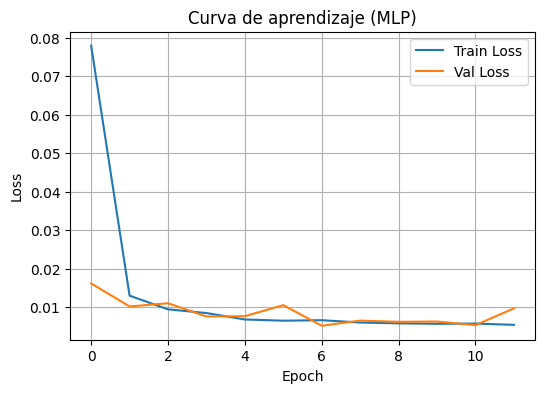

In [43]:
epochs=200
batch_size=1024
lr=0.003
patience=5
model = train_model(
    mlp, Xtr, ytr, Xte, yte, 
    epochs=epochs, 
    bs=batch_size, lr=lr,
    patience=patience
)

In [55]:
device = "cuda" if torch.cuda.is_available() else "cpu"

mlp_trained = model.to(device)

# Pasa Xte al mismo device
with torch.no_grad():
    Xte_t = torch.tensor(Xte, dtype=torch.float32).to(device)
    logits_test = mlp_trained(Xte_t)             # logits en device
    proba_mlp = F.softmax(logits_test, dim=1)    # aplicar softmax
    proba_mlp = proba_mlp.cpu().numpy()   

/tmp/ipykernel_21/3673076520.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xte_t = torch.tensor(Xte, dtype=torch.float32).to(device)


=== Métricas agregadas ===
Macro     -> P: 0.9943 | R: 0.9892 | F1: 0.9917
Weighted  -> P: 0.9967 | R: 0.9966 | F1: 0.9966

=== Classification report (por clase) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10802
           1       1.00      0.99      1.00     34271
           2       0.99      1.00      1.00     31531
           3       1.00      1.00      1.00      2475
           4       1.00      1.00      1.00     25257
           5       0.99      1.00      1.00      5334
           6       0.98      0.94      0.96        49

    accuracy                           1.00    109719
   macro avg       0.99      0.99      0.99    109719
weighted avg       1.00      1.00      1.00    109719



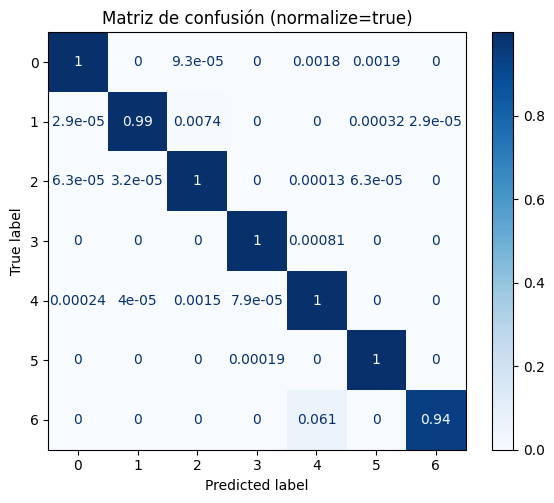


ROC-AUC multiclase:
  micro-average: 1.0000
  macro-average (ovr): 1.0000


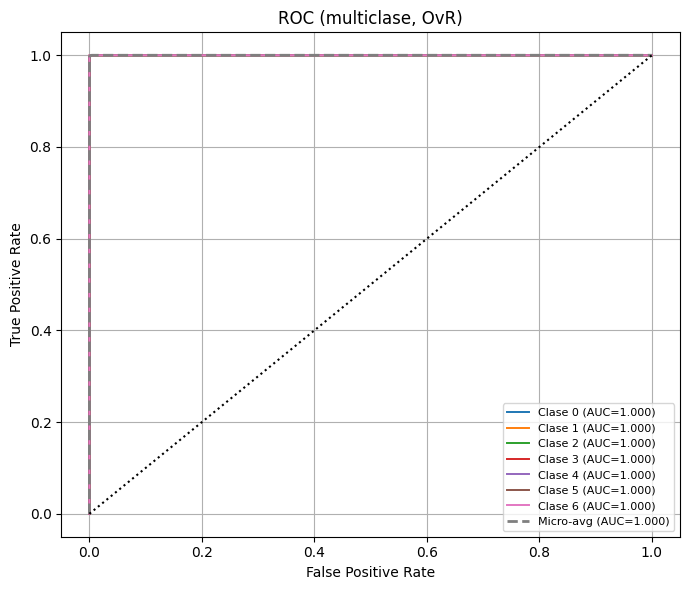


Average Precision multiclase:
  micro-average AP: 1.0000
  clase 0 AP: 1.0000
  clase 1 AP: 1.0000
  clase 2 AP: 1.0000
  clase 3 AP: 1.0000
  clase 4 AP: 1.0000
  clase 5 AP: 1.0000
  clase 6 AP: 0.9974


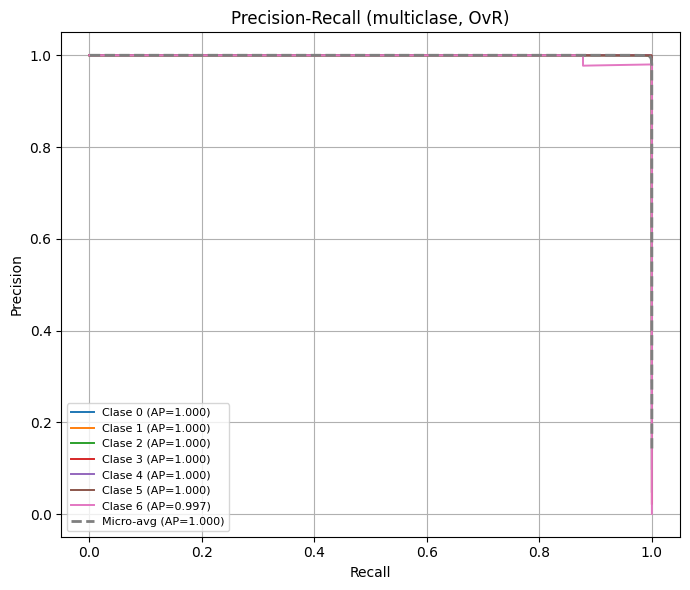

In [58]:
_ = eval_predictions(y_true=yte, y_pred=proba_mlp, plot_cm=True, plot_roc=True, plot_pr=True)

## ConvNet 1D

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

def eval_predictions(
    y_true,
    y_pred,
    threshold=0.5,
    labels=None,
    average='macro',
    multi_class='ovr',
    plot_cm=True,
    cm_normalize='true',   # 'true'|'pred'|'all'|None
    plot_roc=True,
    plot_pr=True,
):
    """
    Evalúa predicciones binarias o multiclase con métricas + gráficos:
    - PR/F1 (macro/weighted), classification_report
    - Matriz de confusión
    - ROC-AUC (binario y multiclase OvR: micro y macro)
    - Curvas ROC por clase + micro
    - Curvas Precision-Recall por clase + micro (AP)
    
    y_true: (n_samples,) etiquetas verdaderas (strings o ints)
    y_pred:
      * binario: prob. clase positiva (n_samples,)
      * multiclase: probs por clase (n_samples, n_classes)
      * etiquetas discretas (sin probas) también funciona, pero sin ROC/PR
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    le = LabelEncoder()
    y_true_enc = le.fit_transform(y_true)
    
    if labels is None:
        class_names = le.classes_
    else:
        class_names = np.asarray(labels)
    
    # Fuerza a string para evitar TypeError con numpy.int64
    class_names_str = [str(c) for c in class_names]
    
    n_classes = len(np.unique(y_true_enc))

    results = {}

    # Detectar formato de y_pred
    proba_available = False
    multiclass = n_classes > 2

    if y_pred.ndim == 1:
        # Puede ser: etiquetas discretas o probas binario
        if set(np.unique(y_pred)).issubset(set(range(n_classes))) and y_pred.dtype.kind in "iu":
            # y_pred son etiquetas (no probabilidades)
            y_pred_labels = y_pred.astype(int)
        else:
            # Se asume probas binario
            proba_available = True
            multiclass = False
            y_pred_labels = (y_pred > threshold).astype(int)
    elif y_pred.ndim == 2:
        # Multiclase con probas
        proba_available = True
        multiclass = True
        if y_pred.shape[1] != n_classes:
            raise ValueError("y_pred de shape (n_samples, n_classes). #clases no coincide con y_true.")
        y_pred_labels = np.argmax(y_pred, axis=1)
    else:
        raise ValueError("Formato de y_pred no soportado.")

    # ---- Métricas de clasificación ----
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true_enc, y_pred_labels, average='macro', zero_division=0
    )
    prec_weight, rec_weight, f1_weight, _ = precision_recall_fscore_support(
        y_true_enc, y_pred_labels, average='weighted', zero_division=0
    )

    print("=== Métricas agregadas ===")
    print(f"Macro     -> P: {prec_macro:.4f} | R: {rec_macro:.4f} | F1: {f1_macro:.4f}")
    print(f"Weighted  -> P: {prec_weight:.4f} | R: {rec_weight:.4f} | F1: {f1_weight:.4f}")

    cr = classification_report(y_true_enc, y_pred_labels, target_names=class_names_str, zero_division=0)
    print("\n=== Classification report (por clase) ===")
    print(cr)

    results.update({
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
        "f1_macro": f1_macro,
        "precision_weighted": prec_weight,
        "recall_weighted": rec_weight,
        "f1_weighted": f1_weight,
        "classification_report_str": cr,
        "y_pred_labels": y_pred_labels
    })

    # ---- Matriz de confusión ----
    if plot_cm:
        cm = confusion_matrix(y_true_enc, y_pred_labels, normalize=cm_normalize)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_str)
        fig, ax = plt.subplots(figsize=(6,5))
        disp.plot(ax=ax, cmap="Blues", colorbar=True)
        ax.set_title("Matriz de confusión" + (f" (normalize={cm_normalize})" if cm_normalize else ""))
        plt.tight_layout(); plt.show()
        results["confusion_matrix"] = cm

    # Si no hay probabilidades no podemos trazar ROC/PR
    if not proba_available:
        return results

    # ---- ROC ----
    if not multiclass:
        fpr, tpr, thr = roc_curve(y_true_enc, y_pred, pos_label=1)
        roc_auc = auc(fpr, tpr)
        print(f"\nROC-AUC (binario): {roc_auc:.4f}")
        if plot_roc:
            plt.figure(figsize=(6,5))
            plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC={roc_auc:.3f})')
            plt.plot([0,1],[0,1], linestyle='--')
            plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
            plt.title('ROC (binario)')
            plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
        results.update({"roc_auc": roc_auc, "roc_curve": {"fpr": fpr, "tpr": tpr, "thresholds": thr}})
    else:
        y_true_bin = label_binarize(y_true_enc, classes=np.arange(n_classes))
        fpr_d, tpr_d, auc_d = {}, {}, {}
        for c in range(n_classes):
            fpr_d[c], tpr_d[c], _ = roc_curve(y_true_bin[:,c], y_pred[:,c])
            auc_d[c] = auc(fpr_d[c], tpr_d[c])

        # micro y macro
        fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_pred.ravel())
        auc_micro = auc(fpr_micro, tpr_micro)
        auc_macro = roc_auc_score(y_true_enc, y_pred, multi_class=multi_class, average="macro")
        print("\nROC-AUC multiclase:")
        print(f"  micro-average: {auc_micro:.4f}")
        print(f"  macro-average ({multi_class}): {auc_macro:.4f}")

        if plot_roc:
            plt.figure(figsize=(7,6))
            for c in range(n_classes):
                plt.plot(fpr_d[c], tpr_d[c], lw=1.4, label=f"Clase {class_names_str[c]} (AUC={auc_d[c]:.3f})")
            plt.plot(fpr_micro, tpr_micro, lw=2, linestyle='--', label=f"Micro-avg (AUC={auc_micro:.3f})")
            plt.plot([0,1],[0,1], linestyle=':', color='black')
            plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
            plt.title('ROC (multiclase, OvR)')
            plt.legend(loc='lower right', fontsize=8)
            plt.grid(True); plt.tight_layout(); plt.show()

        results.update({
            "roc_auc_micro": auc_micro,
            "roc_auc_macro": auc_macro,
            "roc_auc_per_class": auc_d
        })

    # ---- Precision-Recall ----
    if not multiclass:
        prec, rec, thr = precision_recall_curve(y_true_enc, y_pred, pos_label=1)
        ap = average_precision_score(y_true_enc, y_pred)
        print(f"\nAverage Precision (binario): {ap:.4f}")
        if plot_pr:
            plt.figure(figsize=(6,5))
            plt.plot(rec, prec, lw=2, label=f'PR (AP={ap:.3f})')
            plt.xlabel('Recall'); plt.ylabel('Precision')
            plt.title('Precision-Recall (binario)')
            plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
        results.update({"ap": ap, "pr_curve": {"precision": prec, "recall": rec, "thresholds": thr}})
    else:
        y_true_bin = label_binarize(y_true_enc, classes=np.arange(n_classes))
        pr_d, rc_d, ap_d = {}, {}, {}
        for c in range(n_classes):
            prec_c, rec_c, _ = precision_recall_curve(y_true_bin[:,c], y_pred[:,c])
            ap_c = average_precision_score(y_true_bin[:,c], y_pred[:,c])
            pr_d[c], rc_d[c], ap_d[c] = prec_c, rec_c, ap_c

        # Micro-average PR
        prec_micro, rec_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_pred.ravel())
        ap_micro = average_precision_score(y_true_bin, y_pred, average="micro")

        print("\nAverage Precision multiclase:")
        print(f"  micro-average AP: {ap_micro:.4f}")
        for c in range(n_classes):
            print(f"  clase {class_names_str[c]} AP: {ap_d[c]:.4f}")

        if plot_pr:
            plt.figure(figsize=(7,6))
            for c in range(n_classes):
                plt.plot(rc_d[c], pr_d[c], lw=1.4, label=f"Clase {class_names_str[c]} (AP={ap_d[c]:.3f})")
            plt.plot(rec_micro, prec_micro, lw=2, linestyle='--', label=f"Micro-avg (AP={ap_micro:.3f})")
            plt.xlabel('Recall'); plt.ylabel('Precision')
            plt.title('Precision-Recall (multiclase, OvR)')
            plt.legend(loc='lower left', fontsize=8)
            plt.grid(True); plt.tight_layout(); plt.show()

        results.update({
            "ap_micro": ap_micro,
            "ap_per_class": ap_d
        })

    return results


In [ ]:
Xtr

# --- ConvNet 1D en PyTorch ---
class Conv1DNet(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1,16,3,padding=1), nn.ReLU(),
            nn.Conv1d(16,32,3,padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(32, out_dim)
    def forward(self, x):
        x = x.unsqueeze(1) # [batch,1,features]
        z = self.conv(x).squeeze(-1)
        return self.fc(z)

conv = Conv1DNet(Xtr.shape[1], len(np.unique(labels)))
print("\nConvNet 1D:")
train_model(conv, Xtr, ytr, Xte, yte)